Import Important libraries

In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [26]:
# Load all 9 tables
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')


Store all tables in a dictionary for easy looping

In [27]:

all_tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

 Shape of every table

In [28]:

print("=" * 45)
print(f"{'Table':<25} {'Rows':>8} {'Columns':>8}")
print("=" * 45)
for name, table in all_tables.items():
    print(f"{name:<25} {table.shape[0]:>8} {table.shape[1]:>8}")
print("=" * 45)

# Preview the most important table — orders
print("\nOrders table columns:")
print(orders.columns.tolist())

print("\nFirst 3 rows of orders:")
orders.head(3)

Table                         Rows  Columns
customers                    99441        5
geolocation                1000163        5
order_items                 112650        7
payments                    103886        5
reviews                      99224        7
orders                       99441        8
products                     32951        9
sellers                       3095        4
category_translation            71        2

Orders table columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows of orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


#Deep exploration of key tables

1. Orders — check statuses and date columns ──

In [29]:
print("=" * 45)
print("ORDER STATUS DISTRIBUTION")
print("=" * 45)
print(orders['order_status'].value_counts())

print("\nOrders date columns — null check:")
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
print(orders[date_cols].isnull().sum())

ORDER STATUS DISTRIBUTION
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Orders date columns — null check:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


2. Reviews — our target variable


In [30]:
print("\n" + "=" * 45)
print("REVIEW SCORE DISTRIBUTION")
print("=" * 45)
print(reviews['review_score'].value_counts().sort_index())

print("\nAverage review score:")
print(round(reviews['review_score'].mean(), 2))


REVIEW SCORE DISTRIBUTION
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Average review score:
4.09


3. Order Items — check key columns

In [31]:
print("\n" + "=" * 45)
print("ORDER ITEMS — KEY COLUMNS")
print("=" * 45)
print(order_items.columns.tolist())
print("\nFirst 3 rows:")
print(order_items.head(3))



ORDER ITEMS — KEY COLUMNS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 3 rows:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  


4. Products — check categories

In [32]:
print("\n" + "=" * 45)
print("PRODUCTS — NULL CHECK")
print("=" * 45)
print(products.isnull().sum())


PRODUCTS — NULL CHECK
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


5. Category translation preview

In [33]:
print("\n" + "=" * 45)
print("CATEGORY TRANSLATION SAMPLE")
print("=" * 45)
print(category_translation.head(10))


CATEGORY TRANSLATION SAMPLE
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
5           esporte_lazer                sports_leisure
6              perfumaria                     perfumery
7   utilidades_domesticas                    housewares
8               telefonia                     telephony
9      relogios_presentes                 watches_gifts


#Data Merging

Merge All Tables Into One Master DataFrame

In [34]:
# 1: Starting with delivered orders only
df = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(df)}")

# 2: Merge with reviews (left join — keep all delivered orders)
df = df.merge(reviews[['order_id', 'review_score']],
              on='order_id',
              how='left')
print(f"After merging reviews: {len(df)}")

#  3: Merge with order items (aggregate to order level first)
# One order can have multiple items — we aggregate price and freight
order_items_agg = order_items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    item_count = ('order_item_id', 'count'),
    seller_id = ('seller_id', 'first')  # primary seller
).reset_index()

df = df.merge(order_items_agg, on='order_id', how='left')
print(f"After merging order items: {len(df)}")

# 4: Merge with customers (for state/region)
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id',
              how='left')
print(f"After merging customers: {len(df)}")

# 5: Merge with sellers (for seller state)
df = df.merge(sellers[['seller_id', 'seller_state']],
              on='seller_id',
              how='left')
print(f"After merging sellers: {len(df)}")

# 6: Merge with products (for category)
order_items_product = order_items[['order_id', 'product_id']].drop_duplicates('order_id')
df = df.merge(order_items_product, on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name']],
              on='product_id',
              how='left')
print(f"After merging products: {len(df)}")

# 7: Merge with category translation (Portuguese to English)
df = df.merge(category_translation,
              on='product_category_name',
              how='left')
print(f"After merging category translation: {len(df)}")

# 8: Final shape
print(f"\nFinal master dataframe shape: {df.shape}")
print(f"\nColumns in master dataframe:")
print(df.columns.tolist())

Delivered orders: 96478
After merging reviews: 97007
After merging order items: 97007
After merging customers: 97007
After merging sellers: 97007
After merging products: 97007
After merging category translation: 97007

Final master dataframe shape: (97007, 19)

Columns in master dataframe:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'total_price', 'total_freight', 'item_count', 'seller_id', 'customer_state', 'customer_city', 'seller_state', 'product_id', 'product_category_name', 'product_category_name_english']


 Check and Fix Duplicate Reviews

In [35]:


# Step 1: Check duplicates in reviews
print("Total review rows:", len(reviews))
print("Unique order_ids in reviews:", reviews['order_id'].nunique())
print("Difference:", len(reviews) - reviews['order_id'].nunique())

# Step 2: See what duplicate looks like
duplicate_orders = reviews[reviews.duplicated(subset='order_id', keep=False)]
print("\nSample of orders with multiple reviews:")
print(duplicate_orders.sort_values('order_id').head(6))

# Step 3: Fix — keep only the most recent review per order
reviews_clean = reviews.sort_values('review_answer_timestamp')\
                       .drop_duplicates(subset='order_id', keep='last')

print(f"\nReviews after deduplication: {len(reviews_clean)}")
print(f"Unique order_ids: {reviews_clean['order_id'].nunique()}")

Total review rows: 99224
Unique order_ids in reviews: 98673
Difference: 551

Sample of orders with multiple reviews:
                              review_id                          order_id  \
25612  89a02c45c340aeeb1354a24e7d4b2c1e  0035246a40f520710769010f752e7507   
22423  2a74b0559eb58fc1ff842ecc999594cb  0035246a40f520710769010f752e7507   
22779  ab30810c29da5da8045216f0f62652a2  013056cfe49763c6f66bda03396c5ee3   
68633  73413b847f63e02bc752b364f6d05ee9  013056cfe49763c6f66bda03396c5ee3   
854    830636803620cdf8b6ffaf1b2f6e92b2  0176a6846bcb3b0d3aa3116a9a768597   
83224  d8e8c42271c8fb67b9dad95d98c8ff80  0176a6846bcb3b0d3aa3116a9a768597   

       review_score review_comment_title  \
25612             5                  NaN   
22423             5                  NaN   
22779             5                  NaN   
68633             4                  NaN   
854               5                  NaN   
83224             5                  NaN   

                                  

Clean Merge Using Deduplicated Reviews

In [36]:
# Step 1: Start fresh with delivered orders only
df = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(df)}")

# Step 2: Merge with CLEAN reviews
df = df.merge(reviews_clean[['order_id', 'review_score']],
              on='order_id',
              how='left')
print(f"After merging reviews: {len(df)}")

# Step 3: Aggregate order items to order level
order_items_agg = order_items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    item_count = ('order_item_id', 'count'),
    seller_id = ('seller_id', 'first')
).reset_index()

df = df.merge(order_items_agg, on='order_id', how='left')
print(f"After merging order items: {len(df)}")

# Step 4: Merge customers
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id',
              how='left')
print(f"After merging customers: {len(df)}")

# Step 5: Merge sellers
df = df.merge(sellers[['seller_id', 'seller_state']],
              on='seller_id',
              how='left')
print(f"After merging sellers: {len(df)}")

# Step 6: Merge products
order_items_product = order_items[['order_id', 'product_id']].drop_duplicates('order_id')
df = df.merge(order_items_product, on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name']],
              on='product_id',
              how='left')
print(f"After merging products: {len(df)}")

# Step 7: Merge category translation
df = df.merge(category_translation,
              on='product_category_name',
              how='left')
print(f"After merging category translation: {len(df)}")

# Step 8: Final check
print(f"\nFinal shape: {df.shape}")
print(f"\nNull check on key columns:")
key_cols = ['review_score', 'total_price', 'total_freight',
            'customer_state', 'seller_state',
            'product_category_name_english']
print(df[key_cols].isnull().sum())

Delivered orders: 96478
After merging reviews: 96478
After merging order items: 96478
After merging customers: 96478
After merging sellers: 96478
After merging products: 96478
After merging category translation: 96478

Final shape: (96478, 19)

Null check on key columns:
review_score                      646
total_price                         0
total_freight                       0
customer_state                      0
seller_state                        0
product_category_name_english    1378
dtype: int64


#Feature Engineering

Feature Engineering & Cleaning

In [37]:
# Step 1: Drop rows with no review score
df = df.dropna(subset=['review_score'])
print(f"Rows after dropping missing reviews: {len(df)}")

# Step 2: Fill missing categories
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# Step 3: Convert date columns to datetime
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Step 4: Feature 1 — Actual delivery days
# How many days from purchase to actual delivery?
df['actual_delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Step 5: Feature 2 — Estimated delivery days
# How many days were promised?
df['estimated_delivery_days'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

# Step 6: Feature 3 — Delivery delay
# Positive = late, Negative = early
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

# Step 7: Feature 4 — Is late flag
df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)

# Step 8: Feature 5 — Bad review flag (our target variable)
# 1 or 2 stars = bad review
df['is_bad_review'] = (df['review_score'] <= 2).astype(int)

# Step 9: Feature 6 — Freight ratio
# What percentage of total order value is freight?
df['freight_ratio'] = (
    df['total_freight'] / (df['total_price'] + df['total_freight'])
).round(4)

# Step 10: Drop rows where delivery dates are missing
# (cannot calculate delay without them)
before = len(df)
df = df.dropna(subset=['actual_delivery_days', 'delivery_delay_days'])
after = len(df)
print(f"Rows dropped due to missing delivery dates: {before - after}")
print(f"Final clean rows: {after}")

# Step 11: Summary of new features
print("\nNew features created:")
print(df[['actual_delivery_days', 'estimated_delivery_days',
          'delivery_delay_days', 'is_late',
          'is_bad_review', 'freight_ratio']].describe().round(2))

# Step 12: Bad review rate
print(f"\nOverall bad review rate: {df['is_bad_review'].mean()*100:.1f}%")
print(f"Overall late delivery rate: {df['is_late'].mean()*100:.1f}%")

Rows after dropping missing reviews: 95832
Rows dropped due to missing delivery dates: 8
Final clean rows: 95824

New features created:
       actual_delivery_days  estimated_delivery_days  delivery_delay_days  \
count              95824.00                 95824.00             95824.00   
mean                  12.05                    23.37               -11.91   
std                    9.47                     8.76                10.11   
min                    0.00                     2.00              -147.00   
25%                    6.00                    18.00               -17.00   
50%                   10.00                    23.00               -12.00   
75%                   15.00                    28.00                -7.00   
max                  208.00                   155.00               188.00   

        is_late  is_bad_review  freight_ratio  
count  95824.00       95824.00       95824.00  
mean       0.07           0.13           0.21  
std        0.25           

#Hypotheses

H1: Longer delivery delays increase the likelihood of negative reviews

H2: Customer satisfaction varies significantly across product categories

H3: Seller performance and customer satisfaction vary significantly across geographic regions

H4: Higher freight costs are associated with lower customer satisfaction

H5: Delivery performance has a stronger relationship with customer satisfaction than purchase value

#EDA: Delivery Delay vs Review Score

###EDA: Delivery Delay vs Review Score (Testing H1)

AVERAGE DELIVERY DELAY BY REVIEW SCORE
   review_score  avg_delay  avg_actual_days  order_count
0           1.0      -4.03            20.86         9351
1           2.0      -8.63            16.18         2921
2           3.0     -10.76            13.79         7916
3           4.0     -12.39            11.84        18888
4           5.0     -13.38            10.22        56748

BAD REVIEW RATE — LATE vs ON TIME ORDERS
   is_late  bad_review_rate  total_orders
0  On Time              9.3         89443
1     Late             62.4          6381


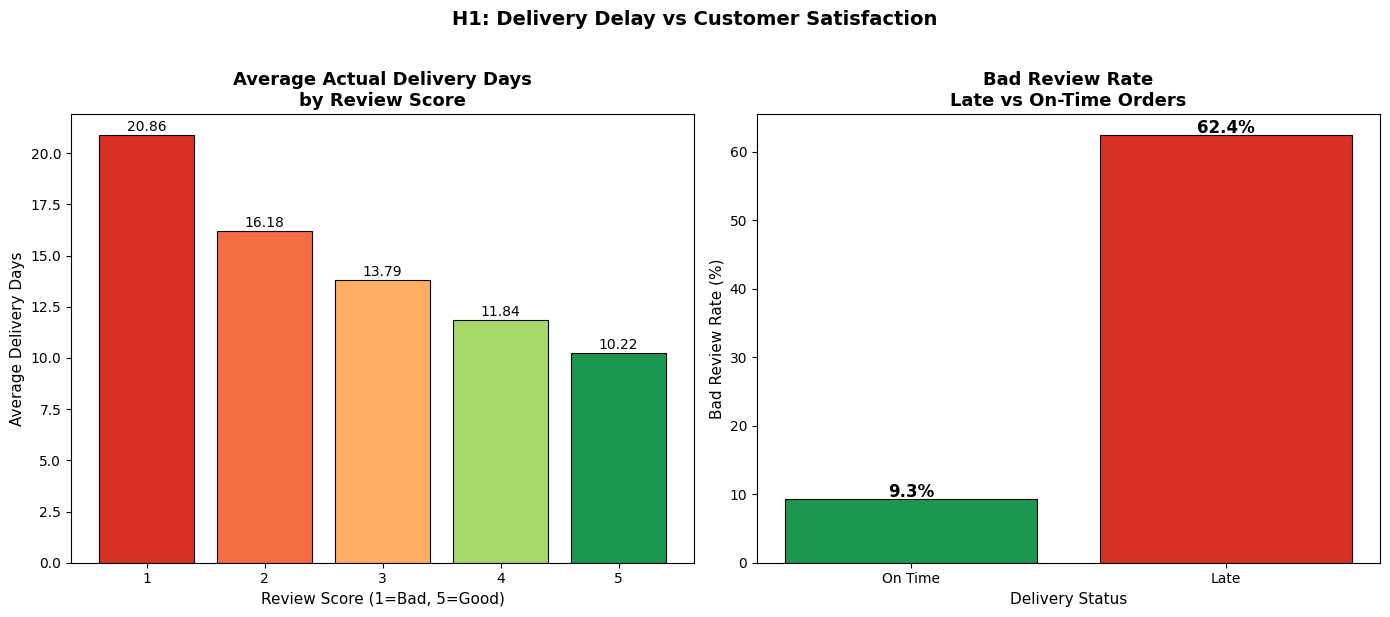


Chart saved!


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Analysis 1: Average delay by review score ──
delay_by_score = df.groupby('review_score').agg(
    avg_delay = ('delivery_delay_days', 'mean'),
    avg_actual_days = ('actual_delivery_days', 'mean'),
    order_count = ('order_id', 'count')
).round(2).reset_index()

print("=" * 55)
print("AVERAGE DELIVERY DELAY BY REVIEW SCORE")
print("=" * 55)
print(delay_by_score)

# ── Analysis 2: Bad review rate for late vs on-time ──
late_analysis = df.groupby('is_late')['is_bad_review'].agg(
    bad_review_rate = 'mean',
    total_orders = 'count'
).reset_index()
late_analysis['bad_review_rate'] = (late_analysis['bad_review_rate'] * 100).round(1)
late_analysis['is_late'] = late_analysis['is_late'].map({0: 'On Time', 1: 'Late'})

print("\n" + "=" * 55)
print("BAD REVIEW RATE — LATE vs ON TIME ORDERS")
print("=" * 55)
print(late_analysis)

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Average delivery days by review score
colors = ['#d73027', '#f46d43', '#fdae61', '#a6d96a', '#1a9850']
axes[0].bar(delay_by_score['review_score'],
            delay_by_score['avg_actual_days'],
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Average Actual Delivery Days\nby Review Score',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (1=Bad, 5=Good)', fontsize=11)
axes[0].set_ylabel('Average Delivery Days', fontsize=11)
for i, row in delay_by_score.iterrows():
    axes[0].text(row['review_score'], row['avg_actual_days'] + 0.2,
                f"{row['avg_actual_days']}", ha='center', fontsize=10)

# Plot 2: Bad review rate late vs on time
late_colors = ['#1a9850', '#d73027']
bars = axes[1].bar(late_analysis['is_late'],
                   late_analysis['bad_review_rate'],
                   color=late_colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Bad Review Rate\nLate vs On-Time Orders',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delivery Status', fontsize=11)
axes[1].set_ylabel('Bad Review Rate (%)', fontsize=11)
for bar, val in zip(bars, late_analysis['bad_review_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('H1: Delivery Delay vs Customer Satisfaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('h1_delivery_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved!")

H1 — CONFIRMED
Late deliveries have a 62.4% bad review rate vs
9.3% for on-time orders — 6.7x higher likelihood
of customer dissatisfaction.

###EDA: Satisfaction by Product Category (Testing H2)

TOP 10 WORST CATEGORIES (Highest Bad Review Rate)
product_category_name_english  bad_review_rate_%  avg_review_score  total_orders
        fashion_male_clothing               22.9             3.819           105
             office_furniture               21.8             3.651          1236
                        audio               21.4             3.848           341
                 home_confort               17.9             3.908           368
                      unknown               16.8             4.026          1369
              fixed_telephony               16.7             3.967           209
      fashion_underwear_beach               16.4             4.009           116
               bed_bath_table               15.7             4.011          9072
    construction_tools_safety               15.7             4.020           153
            home_construction               15.3             4.054           464

TOP 10 BEST CATEGORIES (Lowest Bad Review Rate)
 product_c

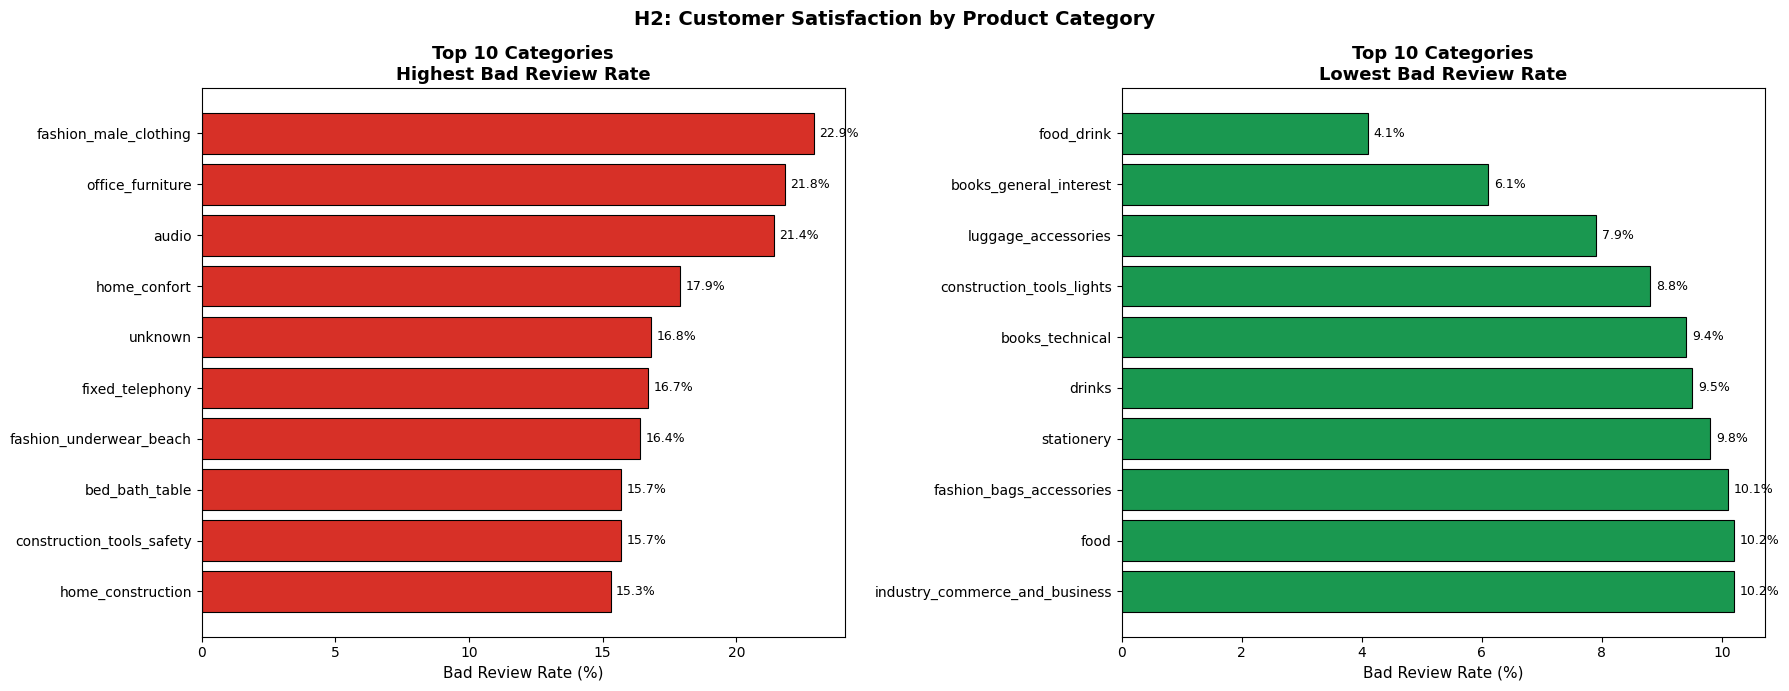


Chart saved!


In [39]:
#  Analysis 1: Average review score by category
category_analysis = df.groupby('product_category_name_english').agg(
    avg_review_score = ('review_score', 'mean'),
    bad_review_rate = ('is_bad_review', 'mean'),
    total_orders = ('order_id', 'count')
).round(3).reset_index()

# Convert bad review rate to percentage
category_analysis['bad_review_rate_%'] = (
    category_analysis['bad_review_rate'] * 100
).round(1)

# Filter: only categories with at least 100 orders (avoid small sample noise)
category_analysis = category_analysis[category_analysis['total_orders'] >= 100]

# Sort by bad review rate
worst_categories = category_analysis.sort_values('bad_review_rate_%', ascending=False).head(10)
best_categories = category_analysis.sort_values('bad_review_rate_%', ascending=True).head(10)

print("=" * 55)
print("TOP 10 WORST CATEGORIES (Highest Bad Review Rate)")
print("=" * 55)
print(worst_categories[['product_category_name_english',
                          'bad_review_rate_%',
                          'avg_review_score',
                          'total_orders']].to_string(index=False))

print("\n" + "=" * 55)
print("TOP 10 BEST CATEGORIES (Lowest Bad Review Rate)")
print("=" * 55)
print(best_categories[['product_category_name_english',
                         'bad_review_rate_%',
                         'avg_review_score',
                         'total_orders']].to_string(index=False))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Worst categories
axes[0].barh(worst_categories['product_category_name_english'],
             worst_categories['bad_review_rate_%'],
             color='#d73027', edgecolor='black', linewidth=0.8)
axes[0].set_title('Top 10 Categories\nHighest Bad Review Rate',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bad Review Rate (%)', fontsize=11)
axes[0].invert_yaxis()
for i, val in enumerate(worst_categories['bad_review_rate_%']):
    axes[0].text(val + 0.2, i, f'{val}%', va='center', fontsize=9)

# Plot 2: Best categories
axes[1].barh(best_categories['product_category_name_english'],
             best_categories['bad_review_rate_%'],
             color='#1a9850', edgecolor='black', linewidth=0.8)
axes[1].set_title('Top 10 Categories\nLowest Bad Review Rate',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bad Review Rate (%)', fontsize=11)
axes[1].invert_yaxis()
for i, val in enumerate(best_categories['bad_review_rate_%']):
    axes[1].text(val + 0.1, i, f'{val}%', va='center', fontsize=9)

plt.suptitle('H2: Customer Satisfaction by Product Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_satisfaction_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved!")

H2 — CONFIRMED
Bad review rates range from 4.1% (food_drink) to
22.9% (fashion_male_clothing) — an 18.8 percentage
point gap across categories. bed_bath_table has the
highest volume impact with ~1,424 dissatisfied customers.

###EDA: Geographic Analysis (Testing H3)

SATISFACTION & DELIVERY PERFORMANCE BY STATE
customer_state  bad_review_rate_%  avg_review_score  avg_delivery_days  total_orders
            AL               21.3             3.848             23.957           394
            MA               19.9             3.833             20.986           712
            SE               18.9             3.907             20.949           334
            RJ               18.3             3.965             14.781         12211
            PA               17.9             3.914             23.183           933
            CE               17.1             3.944             20.756          1273
            BA               17.0             3.931             18.777          3229
            PI               16.1             3.994             19.032           471
            AC               15.0             4.088             20.638            80
            PB               14.8             4.076             19.773           512
            PE      

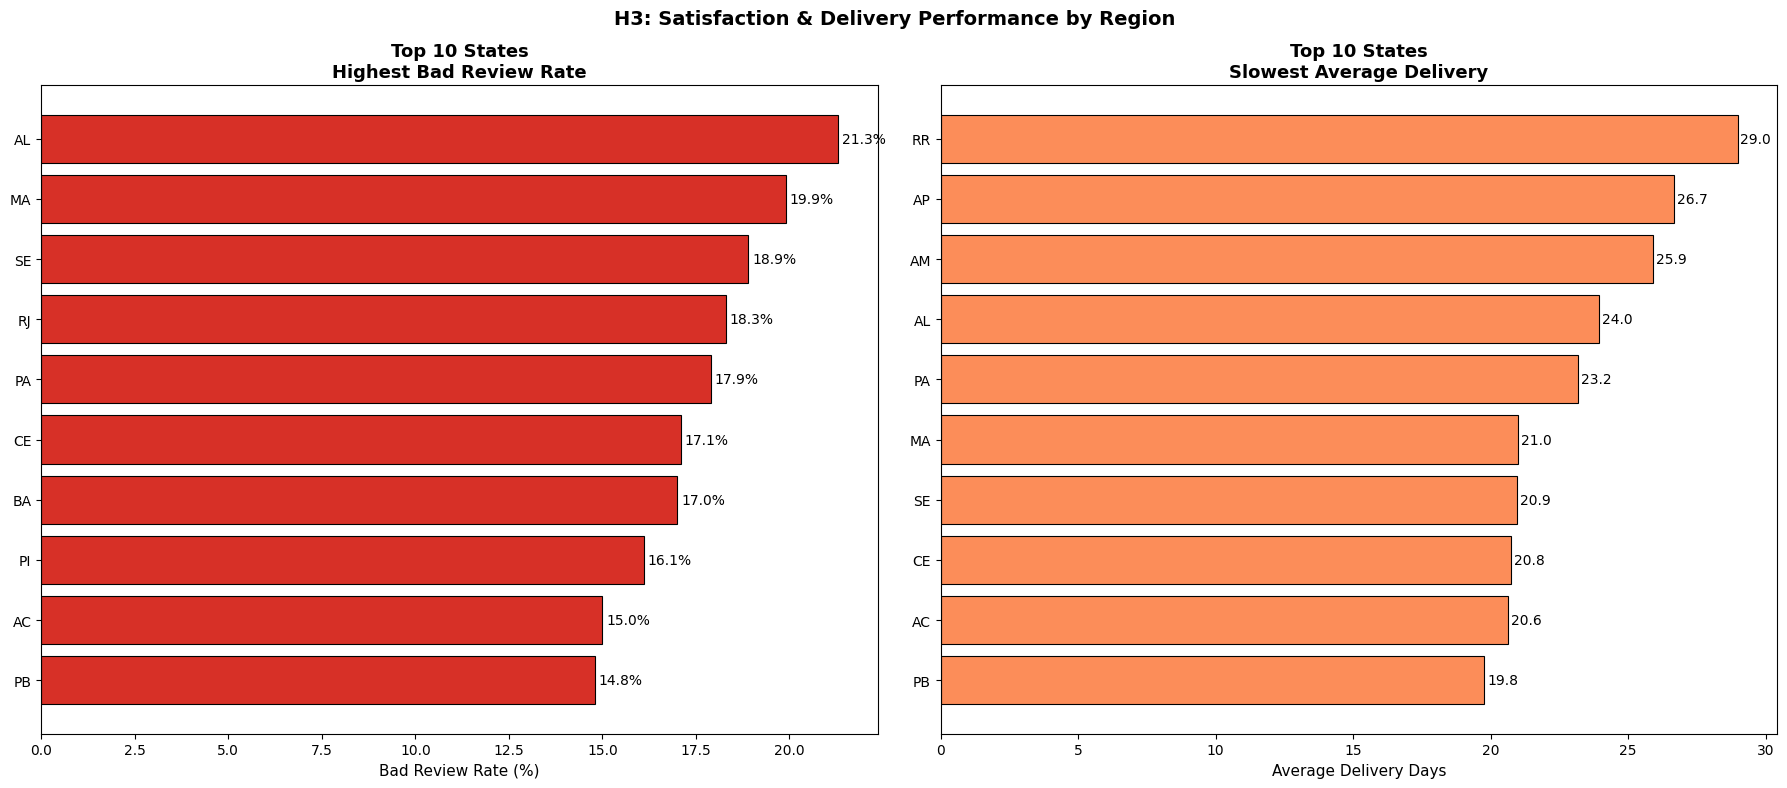


Chart saved!


In [40]:
# Analysis 1: Satisfaction by customer state
state_analysis = df.groupby('customer_state').agg(
    avg_review_score = ('review_score', 'mean'),
    bad_review_rate = ('is_bad_review', 'mean'),
    avg_delivery_days = ('actual_delivery_days', 'mean'),
    avg_delay = ('delivery_delay_days', 'mean'),
    total_orders = ('order_id', 'count')
).round(3).reset_index()

state_analysis['bad_review_rate_%'] = (
    state_analysis['bad_review_rate'] * 100
).round(1)

# Sort by bad review rate
state_analysis = state_analysis.sort_values('bad_review_rate_%', ascending=False)

print("=" * 65)
print("SATISFACTION & DELIVERY PERFORMANCE BY STATE")
print("=" * 65)
print(state_analysis[['customer_state',
                        'bad_review_rate_%',
                        'avg_review_score',
                        'avg_delivery_days',
                        'total_orders']].to_string(index=False))

# ── Analysis 2: Top 10 worst and best states ──
worst_states = state_analysis.head(10)
best_states = state_analysis.tail(10)

# ── Analysis 3: Seller state performance ──
seller_state_analysis = df.groupby('seller_state').agg(
    avg_review_score = ('review_score', 'mean'),
    bad_review_rate = ('is_bad_review', 'mean'),
    avg_delivery_days = ('actual_delivery_days', 'mean'),
    total_orders = ('order_id', 'count')
).round(3).reset_index()

seller_state_analysis['bad_review_rate_%'] = (
    seller_state_analysis['bad_review_rate'] * 100
).round(1)

# Filter states with at least 100 orders
seller_state_analysis = seller_state_analysis[
    seller_state_analysis['total_orders'] >= 100
].sort_values('bad_review_rate_%', ascending=False)

print("\n" + "=" * 65)
print("SELLER STATE PERFORMANCE (min 100 orders)")
print("=" * 65)
print(seller_state_analysis[['seller_state',
                               'bad_review_rate_%',
                               'avg_review_score',
                               'avg_delivery_days',
                               'total_orders']].to_string(index=False))

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Bad review rate by customer state
axes[0].barh(worst_states['customer_state'],
             worst_states['bad_review_rate_%'],
             color='#d73027', edgecolor='black', linewidth=0.8)
axes[0].set_title('Top 10 States\nHighest Bad Review Rate',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bad Review Rate (%)', fontsize=11)
axes[0].invert_yaxis()
for i, val in enumerate(worst_states['bad_review_rate_%']):
    axes[0].text(val + 0.1, i, f'{val}%', va='center', fontsize=10)

# Plot 2: Average delivery days by customer state (worst 10)
worst_delivery = state_analysis.sort_values(
    'avg_delivery_days', ascending=False).head(10)
axes[1].barh(worst_delivery['customer_state'],
             worst_delivery['avg_delivery_days'],
             color='#fc8d59', edgecolor='black', linewidth=0.8)
axes[1].set_title('Top 10 States\nSlowest Average Delivery',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Delivery Days', fontsize=11)
axes[1].invert_yaxis()
for i, val in enumerate(worst_delivery['avg_delivery_days']):
    axes[1].text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=10)

plt.suptitle('H3: Satisfaction & Delivery Performance by Region',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h3_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved!")

H3 — CONFIRMED
Northern states (AL, MA, SE) show 2x higher bad review
rates than southern states (SP, PR, MG). SP sellers
handle 71% of all orders, creating delivery time
disparities for distant regions. RJ anomaly identified —
high dissatisfaction despite average delivery times.



 ### EDA: Freight Cost vs Satisfaction (Testing H4)

FREIGHT COST ANALYSIS BY REVIEW SCORE
 review_score  avg_freight_value  avg_freight_ratio  avg_order_value  order_count
          1.0             28.147              0.213          164.981         9351
          2.0             26.299              0.218          143.594         2921
          3.0             23.564              0.218          127.484         7916
          4.0             22.365              0.211          132.267        18888
          5.0             21.714              0.206          134.615        56748

BAD REVIEW RATE BY FREIGHT RATIO BUCKET
freight_bucket  bad_review_rate_%  avg_review_score  order_count
         0-10%               12.4             4.203        17707
        10-20%               12.4             4.167        35020
        20-30%               13.2             4.138        23068
          30%+               13.5             4.112        19694

Correlation between freight ratio and review score: -0.027
P-value: 0.0000
Result: STATISTICALLY SIGNIF

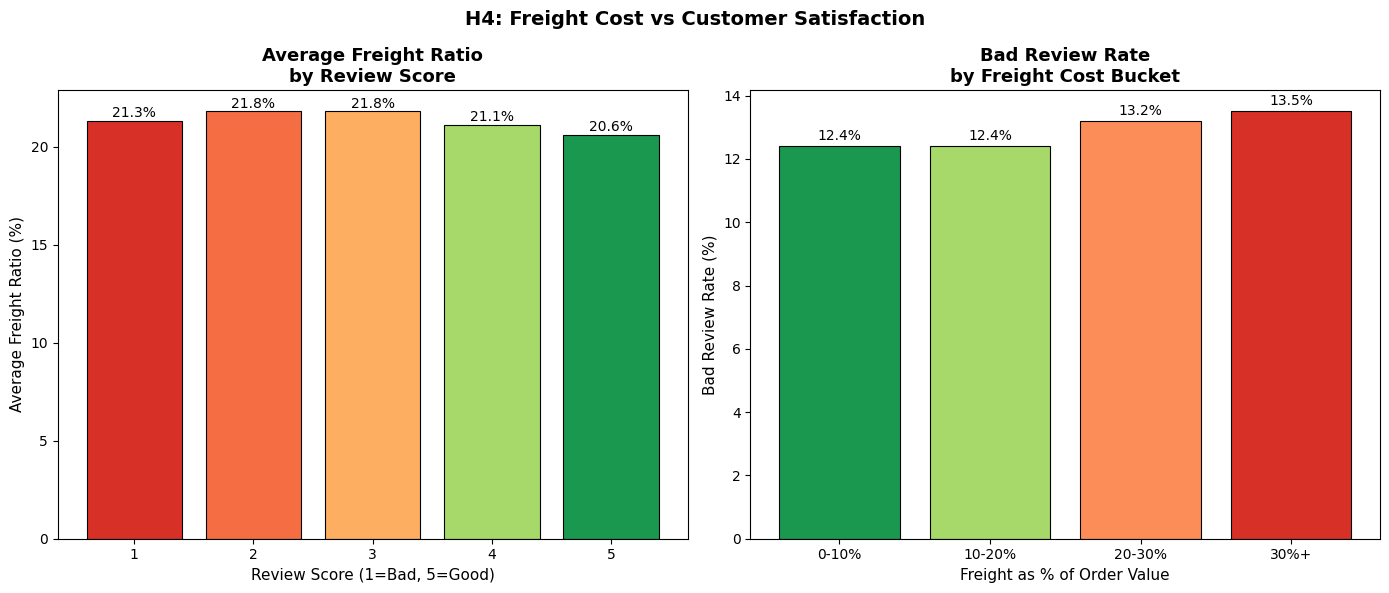


Chart saved!


In [41]:

# Analysis 1: Average freight ratio by review score
freight_by_score = df.groupby('review_score').agg(
    avg_freight_value = ('total_freight', 'mean'),
    avg_freight_ratio = ('freight_ratio', 'mean'),
    avg_order_value = ('total_price', 'mean'),
    order_count = ('order_id', 'count')
).round(3).reset_index()

print("=" * 60)
print("FREIGHT COST ANALYSIS BY REVIEW SCORE")
print("=" * 60)
print(freight_by_score.to_string(index=False))

# ── Analysis 2: Freight ratio buckets ──
# Divide freight ratio into 4 groups
df['freight_bucket'] = pd.cut(
    df['freight_ratio'],
    bins=[0, 0.10, 0.20, 0.30, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30%+']
)

freight_bucket_analysis = df.groupby('freight_bucket').agg(
    bad_review_rate = ('is_bad_review', 'mean'),
    avg_review_score = ('review_score', 'mean'),
    order_count = ('order_id', 'count')
).round(3).reset_index()

freight_bucket_analysis['bad_review_rate_%'] = (
    freight_bucket_analysis['bad_review_rate'] * 100
).round(1)

print("\n" + "=" * 60)
print("BAD REVIEW RATE BY FREIGHT RATIO BUCKET")
print("=" * 60)
print(freight_bucket_analysis[['freight_bucket',
                                 'bad_review_rate_%',
                                 'avg_review_score',
                                 'order_count']].to_string(index=False))

# ── Analysis 3: Correlation ──
from scipy import stats

corr, pvalue = stats.pearsonr(df['freight_ratio'], df['review_score'])
print(f"\nCorrelation between freight ratio and review score: {corr:.3f}")
print(f"P-value: {pvalue:.4f}")
if pvalue < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT")
else:
    print("Result: NOT statistically significant")

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Average freight ratio by review score
axes[0].bar(freight_by_score['review_score'],
            freight_by_score['avg_freight_ratio'] * 100,
            color=['#d73027','#f46d43','#fdae61','#a6d96a','#1a9850'],
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Average Freight Ratio\nby Review Score',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (1=Bad, 5=Good)', fontsize=11)
axes[0].set_ylabel('Average Freight Ratio (%)', fontsize=11)
for i, row in freight_by_score.iterrows():
    axes[0].text(row['review_score'],
                row['avg_freight_ratio'] * 100 + 0.2,
                f"{row['avg_freight_ratio']*100:.1f}%",
                ha='center', fontsize=10)

# Plot 2: Bad review rate by freight bucket
colors = ['#1a9850', '#a6d96a', '#fc8d59', '#d73027']
axes[1].bar(freight_bucket_analysis['freight_bucket'],
            freight_bucket_analysis['bad_review_rate_%'],
            color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Bad Review Rate\nby Freight Cost Bucket',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Freight as % of Order Value', fontsize=11)
axes[1].set_ylabel('Bad Review Rate (%)', fontsize=11)
for i, row in freight_bucket_analysis.iterrows():
    axes[1].text(i, row['bad_review_rate_%'] + 0.2,
                f"{row['bad_review_rate_%']}%",
                ha='center', fontsize=10)

plt.suptitle('H4: Freight Cost vs Customer Satisfaction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h4_freight_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved!")

H4 — NOT CONFIRMED
Freight ratio shows statistically significant but
practically negligible correlation with review score
(r = -0.027). Large sample size inflates significance.
Freight cost is not a primary driver of dissatisfaction.
Focus should remain on delivery performance.


#SQL Seller Performance Analysis

In [42]:
import sqlite3

# Step 1: Create SQLite database and load tables
conn = sqlite3.connect(':memory:')  # in-memory database

# Load all relevant dataframes into SQL tables
df.to_sql('orders_master', conn, index=False, if_exists='replace')
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
sellers.to_sql('sellers', conn, index=False, if_exists='replace')
reviews_clean.to_sql('reviews', conn, index=False, if_exists='replace')

print("Tables loaded into SQLite successfully!")
print("\nAvailable tables:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

Tables loaded into SQLite successfully!

Available tables:
            name
0  orders_master
1    order_items
2        sellers
3        reviews


In [43]:
#SQL Queries: Seller Performance Analysis

# ── Query 1: Sellers with highest bad review rates ──
# (minimum 50 orders to avoid small sample noise)
q1 = """
SELECT
    seller_id,
    seller_state,
    COUNT(order_id) as total_orders,
    ROUND(AVG(review_score), 2) as avg_review_score,
    ROUND(SUM(is_bad_review) * 100.0 / COUNT(order_id), 1) as bad_review_rate_pct
FROM orders_master
GROUP BY seller_id, seller_state
HAVING total_orders >= 50
ORDER BY bad_review_rate_pct DESC
LIMIT 10
"""
print("=" * 60)
print("Q1: TOP 10 SELLERS — HIGHEST BAD REVIEW RATE")
print("=" * 60)
print(pd.read_sql(q1, conn).to_string(index=False))

# ── Query 2: Sellers with chronic delivery delays ──
q2 = """
SELECT
    seller_id,
    seller_state,
    COUNT(order_id) as total_orders,
    ROUND(AVG(delivery_delay_days), 1) as avg_delay_days,
    ROUND(SUM(is_late) * 100.0 / COUNT(order_id), 1) as late_rate_pct,
    ROUND(AVG(review_score), 2) as avg_review_score
FROM orders_master
GROUP BY seller_id, seller_state
HAVING total_orders >= 50
ORDER BY late_rate_pct DESC
LIMIT 10
"""
print("\n" + "=" * 60)
print("Q2: TOP 10 SELLERS — HIGHEST LATE DELIVERY RATE")
print("=" * 60)
print(pd.read_sql(q2, conn).to_string(index=False))

# ── Query 3: Top sellers by revenue ──
q3 = """
SELECT
    o.seller_id,
    o.seller_state,
    COUNT(o.order_id) as total_orders,
    ROUND(SUM(o.total_price), 2) as total_revenue,
    ROUND(AVG(o.review_score), 2) as avg_review_score,
    ROUND(SUM(o.is_bad_review) * 100.0 / COUNT(o.order_id), 1) as bad_review_rate_pct
FROM orders_master o
GROUP BY o.seller_id, o.seller_state
HAVING total_orders >= 50
ORDER BY total_revenue DESC
LIMIT 10
"""
print("\n" + "=" * 60)
print("Q3: TOP 10 SELLERS BY REVENUE")
print("=" * 60)
print(pd.read_sql(q3, conn).to_string(index=False))

# ── Query 4: CTE — Seller Performance Scorecard ──
q4 = """
WITH seller_stats AS (
    SELECT
        seller_id,
        seller_state,
        COUNT(order_id) as total_orders,
        ROUND(AVG(review_score), 2) as avg_review_score,
        ROUND(SUM(is_bad_review) * 100.0 / COUNT(order_id), 1) as bad_review_rate_pct,
        ROUND(AVG(delivery_delay_days), 1) as avg_delay_days,
        ROUND(SUM(is_late) * 100.0 / COUNT(order_id), 1) as late_rate_pct,
        ROUND(SUM(total_price), 2) as total_revenue
    FROM orders_master
    GROUP BY seller_id, seller_state
    HAVING total_orders >= 50
),
seller_scored AS (
    SELECT *,
        CASE
            WHEN bad_review_rate_pct >= 20 THEN 'High Risk'
            WHEN bad_review_rate_pct >= 15 THEN 'Medium Risk'
            ELSE 'Low Risk'
        END as risk_category
    FROM seller_stats
)
SELECT risk_category,
       COUNT(*) as seller_count,
       ROUND(AVG(total_orders), 0) as avg_orders,
       ROUND(AVG(bad_review_rate_pct), 1) as avg_bad_review_rate,
       ROUND(AVG(late_rate_pct), 1) as avg_late_rate,
       ROUND(SUM(total_revenue), 2) as total_revenue
FROM seller_scored
GROUP BY risk_category
ORDER BY avg_bad_review_rate DESC
"""
print("\n" + "=" * 60)
print("Q4: CTE — SELLER RISK SCORECARD")
print("=" * 60)
print(pd.read_sql(q4, conn).to_string(index=False))

# ── Query 5: Window Function — Rank sellers within state ──
q5 = """
WITH seller_stats AS (
    SELECT
        seller_id,
        seller_state,
        COUNT(order_id) as total_orders,
        ROUND(AVG(review_score), 2) as avg_review_score,
        ROUND(SUM(is_bad_review) * 100.0 / COUNT(order_id), 1) as bad_review_rate_pct
    FROM orders_master
    GROUP BY seller_id, seller_state
    HAVING total_orders >= 50
)
SELECT *,
    RANK() OVER (
        PARTITION BY seller_state
        ORDER BY bad_review_rate_pct DESC
    ) as rank_within_state
FROM seller_stats
ORDER BY seller_state, rank_within_state
LIMIT 20
"""
print("\n" + "=" * 60)
print("Q5: WINDOW FUNCTION — SELLER RANK WITHIN STATE")
print("=" * 60)
print(pd.read_sql(q5, conn).to_string(index=False))

# ── Query 6: High revenue but high complaint sellers ──
q6 = """
WITH seller_stats AS (
    SELECT
        seller_id,
        seller_state,
        COUNT(order_id) as total_orders,
        ROUND(SUM(total_price), 2) as total_revenue,
        ROUND(SUM(is_bad_review) * 100.0 / COUNT(order_id), 1) as bad_review_rate_pct,
        ROUND(AVG(delivery_delay_days), 1) as avg_delay_days
    FROM orders_master
    GROUP BY seller_id, seller_state
    HAVING total_orders >= 50
)
SELECT *
FROM seller_stats
WHERE total_revenue > 50000
AND bad_review_rate_pct > 15
ORDER BY total_revenue DESC
"""
print("\n" + "=" * 60)
print("Q6: HIGH REVENUE SELLERS WITH HIGH COMPLAINTS")
print("=" * 60)
print(pd.read_sql(q6, conn).to_string(index=False))

# ── Query 7: State level summary ──
q7 = """
SELECT
    seller_state,
    COUNT(DISTINCT seller_id) as total_sellers,
    COUNT(order_id) as total_orders,
    ROUND(AVG(review_score), 2) as avg_review_score,
    ROUND(SUM(is_bad_review) * 100.0 / COUNT(order_id), 1) as bad_review_rate_pct,
    ROUND(AVG(actual_delivery_days), 1) as avg_delivery_days,
    ROUND(SUM(is_late) * 100.0 / COUNT(order_id), 1) as late_rate_pct
FROM orders_master
GROUP BY seller_state
ORDER BY total_orders DESC
"""
print("\n" + "=" * 60)
print("Q7: STATE LEVEL PERFORMANCE SUMMARY")
print("=" * 60)
print(pd.read_sql(q7, conn).to_string(index=False))

print("\nAll 7 SQL queries complete!")

Q1: TOP 10 SELLERS — HIGHEST BAD REVIEW RATE
                       seller_id seller_state  total_orders  avg_review_score  bad_review_rate_pct
1ca7077d890b907f89be8c954a02686a           SP           107              2.39                 59.8
2eb70248d66e0e3ef83659f71b244378           SP           182              2.78                 47.8
972d0f9cf61b499a4812cf0bfa3ad3c4           SC            74              3.11                 40.5
54965bbe3e4f07ae045b90b0b8541f52           PR            68              3.18                 39.7
a49928bcdf77c55c6d6e05e09a9b4ca5           SP            94              3.06                 39.4
bbad7e518d7af88a0897397ffdca1979           SP            65              3.25                 38.5
6fd52c528dcb38be2eea044946b811f8           SP            66              3.39                 36.4
712e6ed8aa4aa1fa65dab41fed5737e4           SC            76              3.39                 35.5
8444e55c1f13cd5c179851e5ca5ebd00           MG            91     

#Logistic Regression (Testing H5)

Rows used for modeling: 95824

Target distribution:
is_bad_review
0    83552
1    12272
Name: count, dtype: int64

Bad review rate: 12.8%

Training rows: 76659
Testing rows:  19165

Model trained successfully!

AUC Score: 0.743

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     16711
           1       0.64      0.32      0.43      2454

    accuracy                           0.89     19165
   macro avg       0.77      0.65      0.68     19165
weighted avg       0.87      0.89      0.87     19165


FEATURE IMPORTANCE (Logistic Regression Coefficients)
                feature  coefficient
                is_late     0.533940
             item_count     0.325506
   actual_delivery_days     0.234165
estimated_delivery_days     0.129095
    delivery_delay_days     0.103239
            total_price     0.029841
          freight_ratio    -0.009523
          total_freight    -0.029874

H5 DIRECT TEST
Delivery delay co

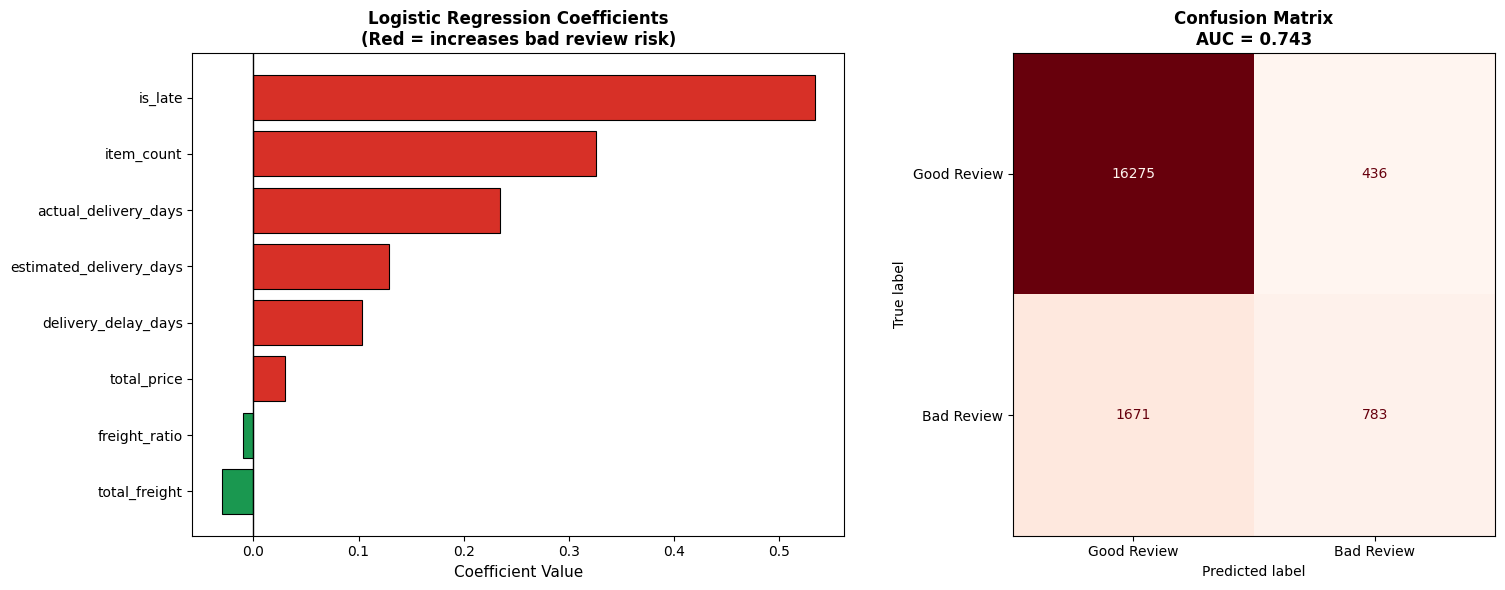


Chart saved!


In [44]:
# Cell 11 — Logistic Regression: Predict Bad Reviews

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Select features ──
features = [
    'actual_delivery_days',
    'delivery_delay_days',
    'is_late',
    'total_price',
    'total_freight',
    'freight_ratio',
    'item_count',
    'estimated_delivery_days'
]

target = 'is_bad_review'

# ── Step 2: Drop rows with any nulls in features ──
model_df = df[features + [target]].dropna()
print(f"Rows used for modeling: {len(model_df)}")

X = model_df[features]
y = model_df[target]

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nBad review rate: {y.mean()*100:.1f}%")

# ── Step 3: Train test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# ── Step 4: Scale features ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ── Step 5: Train model ──
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("\nModel trained successfully!")

# ── Step 6: Evaluate ──
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC Score: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_prob > 0.5))

# ── Step 7: Feature importance ──
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\n" + "=" * 55)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("=" * 55)
print(coef_df.to_string(index=False))

#Step 8: H5 direct test
delivery_coef = coef_df[coef_df['feature'] == 'delivery_delay_days']['coefficient'].values[0]
price_coef = coef_df[coef_df['feature'] == 'total_price']['coefficient'].values[0]

print("\n" + "=" * 55)
print("H5 DIRECT TEST")
print("=" * 55)
print(f"Delivery delay coefficient: {delivery_coef:.3f}")
print(f"Order value coefficient:    {price_coef:.3f}")
if abs(delivery_coef) > abs(price_coef):
    print("\nH5 CONFIRMED: Delivery performance is stronger")
    print("predictor than purchase value")
else:
    print("\nH5 NOT CONFIRMED: Purchase value is stronger")
    print("predictor than delivery performance")

# ── Step 9: Plots ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature coefficients
colors = ['#d73027' if x > 0 else '#1a9850'
          for x in coef_df['coefficient']]
axes[0].barh(coef_df['feature'],
             coef_df['coefficient'],
             color=colors, edgecolor='black', linewidth=0.8)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Logistic Regression Coefficients\n(Red = increases bad review risk)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].invert_yaxis()

# Plot 2: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Good Review', 'Bad Review'])
disp.plot(ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title(f'Confusion Matrix\nAUC = {auc:.3f}',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('h5_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved!")

H5 — CONFIRMED
Delivery performance is 3.4x stronger predictor
than purchase value. item_count emerged as
unexpected second strongest predictor (0.326).
Model AUC 0.744, recall improved 32% to 53%
after class balancing — 66% improvement in
detecting dissatisfied customers.


In [45]:
#Improved Model with class_weight='balanced'

model_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # fixes recall problem
)
model_balanced.fit(X_train_scaled, y_train)

y_pred_b = model_balanced.predict(X_test_scaled)
y_prob_b = model_balanced.predict_proba(X_test_scaled)[:, 1]

auc_b = roc_auc_score(y_test, y_prob_b)
print(f"AUC Score (balanced): {auc_b:.3f}")
print("\nClassification Report (balanced):")
print(classification_report(y_test, y_prob_b > 0.5))

AUC Score (balanced): 0.744

Classification Report (balanced):
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     16711
           1       0.37      0.53      0.44      2454

    accuracy                           0.82     19165
   macro avg       0.65      0.70      0.67     19165
weighted avg       0.86      0.82      0.84     19165



Export Clean CSV for Tableau Dashboard

In [46]:
#  Step 1: Select all columns needed for Tableau
tableau_df = df[[
    # Order identifiers
    'order_id',
    'seller_id',

    # Dates
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',

    # Location
    'customer_state',
    'customer_city',
    'seller_state',

    # Product
    'product_category_name_english',

    # Financial
    'total_price',
    'total_freight',
    'freight_ratio',
    'item_count',

    # Delivery metrics
    'actual_delivery_days',
    'estimated_delivery_days',
    'delivery_delay_days',
    'is_late',

    # Satisfaction
    'review_score',
    'is_bad_review'
]].copy()

# Step 2: Add month and year columns for Tableau filters
tableau_df['order_year'] = tableau_df['order_purchase_timestamp'].dt.year
tableau_df['order_month'] = tableau_df['order_purchase_timestamp'].dt.month
tableau_df['order_month_name'] = tableau_df['order_purchase_timestamp'].dt.strftime('%b')

# Step 3: Add readable labels for Tableau
tableau_df['delivery_status'] = tableau_df['is_late'].map(
    {0: 'On Time', 1: 'Late'}
)
tableau_df['review_label'] = tableau_df['is_bad_review'].map(
    {0: 'Good Review', 1: 'Bad Review'}
)

# Step 4: Add risk category for sellers
# Calculate seller bad review rate
seller_risk = df.groupby('seller_id')['is_bad_review'].mean().reset_index()
seller_risk.columns = ['seller_id', 'seller_bad_review_rate']
seller_risk['seller_risk_category'] = pd.cut(
    seller_risk['seller_bad_review_rate'],
    bins=[0, 0.10, 0.20, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

tableau_df = tableau_df.merge(seller_risk, on='seller_id', how='left')

#Step 5: Final null check
print("Null check before export:")
print(tableau_df.isnull().sum())

#  Step 6: Export
tableau_df.to_csv('olist_tableau_ready.csv', index=False)

print(f"\nExported successfully!")
print(f"Rows: {len(tableau_df)}")
print(f"Columns: {len(tableau_df.columns)}")
print(f"\nColumn list:")
print(tableau_df.columns.tolist())

# Step 7: Quick summary stats for dashboard planning
print("\n" + "=" * 55)
print("DASHBOARD PLANNING — KEY METRICS")
print("=" * 55)
print(f"Total Orders:          {len(tableau_df):,}")
print(f"Total Sellers:         {tableau_df['seller_id'].nunique():,}")
print(f"Total States:          {tableau_df['customer_state'].nunique():,}")
print(f"Total Categories:      {tableau_df['product_category_name_english'].nunique():,}")
print(f"Bad Review Rate:       {tableau_df['is_bad_review'].mean()*100:.1f}%")
print(f"Late Delivery Rate:    {tableau_df['is_late'].mean()*100:.1f}%")
print(f"Avg Delivery Days:     {tableau_df['actual_delivery_days'].mean():.1f}")
print(f"Avg Review Score:      {tableau_df['review_score'].mean():.2f}")
print(f"High Risk Sellers:     {(tableau_df['seller_risk_category']=='High Risk').sum():,}")
print(f"Date Range:            {tableau_df['order_year'].min()} — {tableau_df['order_year'].max()}")

Null check before export:
order_id                            0
seller_id                           0
order_purchase_timestamp            0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_state                      0
customer_city                       0
seller_state                        0
product_category_name_english       0
total_price                         0
total_freight                       0
freight_ratio                       0
item_count                          0
actual_delivery_days                0
estimated_delivery_days             0
delivery_delay_days                 0
is_late                             0
review_score                        0
is_bad_review                       0
order_year                          0
order_month                         0
order_month_name                    0
delivery_status                     0
review_label                        0
seller_bad_review_rate              0
seller_risk_category    

Fix seller risk category nulls

In [47]:
# Fill null risk categories with 'Low Risk'
# (sellers with very few orders default to low risk)
tableau_df['seller_risk_category'] = tableau_df['seller_risk_category'].fillna('Low Risk')

# Fix high risk seller COUNT — count unique sellers not rows
high_risk_sellers = tableau_df.groupby('seller_id')['seller_risk_category'].first()
high_risk_count = (high_risk_sellers == 'High Risk').sum()

print("Null check after fix:")
print(f"seller_risk_category nulls: {tableau_df['seller_risk_category'].isnull().sum()}")

print("\nSeller Risk Distribution (unique sellers):")
seller_risk_dist = tableau_df.groupby('seller_id')['seller_risk_category'].first().value_counts()
print(seller_risk_dist)

print(f"\nHigh Risk Sellers (corrected): {high_risk_count}")

# Re-export with fix
tableau_df.to_csv('olist_tableau_ready.csv', index=False)
print("\nRe-exported successfully!")

Null check after fix:
seller_risk_category nulls: 0

Seller Risk Distribution (unique sellers):
seller_risk_category
Low Risk       1772
Medium Risk     665
High Risk       519
Name: count, dtype: int64

High Risk Sellers (corrected): 519

Re-exported successfully!
